In [1]:
from fredapi import Fred
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.tsa.api import VAR
import pandas as pd
from scipy.stats import kurtosis, skew

In [2]:
def make_yield_df_excess_returns(maturities, rx_maturities):
    df = pd.read_csv('feds200628.csv', skiprows=9)
    df = df[['Date', 'BETA0', 'BETA1', 'BETA2', 'BETA3', 'TAU1', 'TAU2']]
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.query('Date > "1980-01-01"')
    
    # Calculate the yields using the NSS formula for each maturity directly
    n_years = np.array(maturities)
    yields = np.empty((len(df), len(n_years)))
    for i, n in enumerate(n_years):
        term1 = (1 - np.exp(-n / df['TAU1'])) / (n / df['TAU1'])
        term2 = np.exp(-n / df['TAU1'])
        term3 = (1 - np.exp(-n / df['TAU2'])) / (n / df['TAU2'])
        term4 = np.exp(-n / df['TAU2'])
        yields[:, i] = df['BETA0'] + df['BETA1'] * term1 + df['BETA2'] * (term1 - term2) + df['BETA3'] * (term3 - term4)
    
    
    def col_names(mats):
        return [f'{m*12:.0f}m' for m in mats]
    
    yields_df = pd.DataFrame(yields, columns=col_names(n_years), index=pd.to_datetime(df['Date']))
    yields_df = yields_df.loc['1986-12-01':'2012-01-01'].resample('BM').last() / 100
    #display(yields_df)
    # Assuming the yield of the shortest maturity as the risk-free rate (in decimal form)
    
    # Compute log prices (-n * yield) for continuously compounded yield
    log_prices = -yields_df.values * n_years
    assert sum(abs(-yields_df.values[:,2] * 0.25 - log_prices[:,2])) < 1.e-6 # assert scaling is correctly applied to data
    #log_prices = log_prices.values
    rfr_t = -log_prices[:-1,0] #       get time 0, 1,..., T-1 and maturity 1 
    p_t_n = log_prices[:-1, 1:] #     get time 0, 1,..., T-1 and maturities 2, 3,.., N. 
    p_tp1_nm1 = log_prices[1:, :-1] # get time 1, 2,..., T   and maturities 1, 2,.., N-1
    
    rx = p_tp1_nm1 - p_t_n - rfr_t.reshape(-1,1)
    rx_maturities_idx = rx_maturities - 2

    df_rx = pd.DataFrame(rx[:,rx_maturities_idx], columns = col_names(rx_maturities/12), index=yields_df.index[1:])
    
    return yields_df, df_rx

def MLS(Y, Z):
    assert Y.shape[0] < Y.shape[1]
    assert Z.shape[0] < Z.shape[1]
    phi = Y@np.linalg.pinv(Z)
    Y_fitted = phi@Z
    residuals = Y-Y_fitted
    return phi, Y_fitted, residuals


all_maturities = np.arange(1, 121, 1)/12
rx_maturities = np.array([6, 12, 18, 24, 30, 36, 42, 48,  54, 60, 84, 120])

df_yield_all, df_rx = make_yield_df_excess_returns(maturities=all_maturities, rx_maturities=rx_maturities)

# 1 ESTIMATE eq(1) AND CONSTRUCT VARCOV FROM RESIDUALS

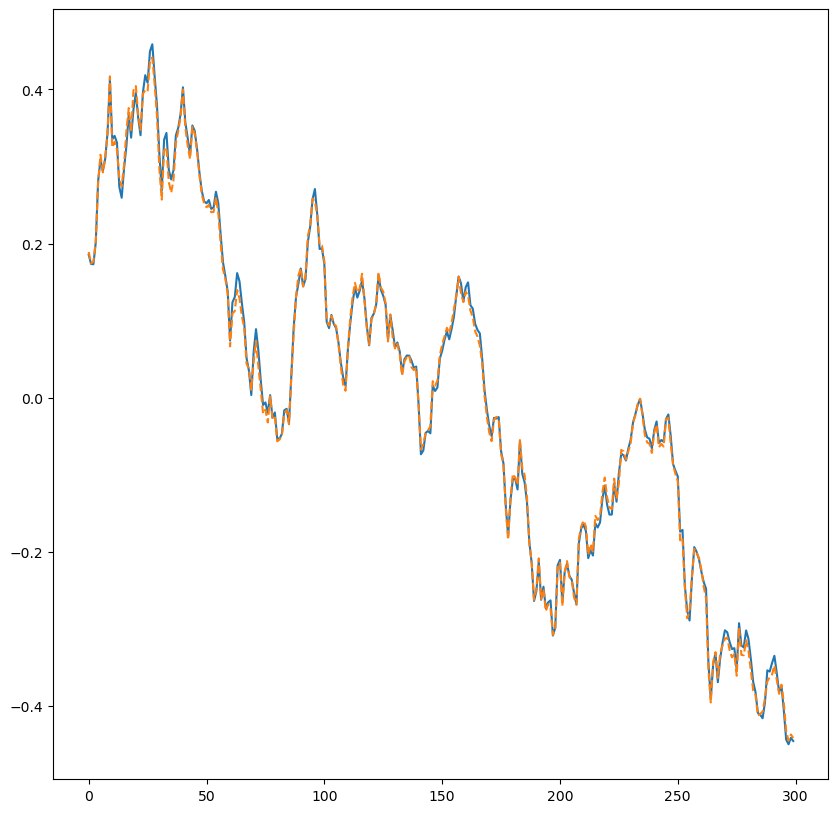

In [48]:
plt.rcParams['figure.figsize'] = [10, 10]


T=300
K = 5
N = 12


# Define and fit PCA
pca_whiten = PCA(n_components=K, whiten=False)

X_maturities_idx = np.arange(3, 121, 1)-1 # subtract due to 0-indexing
pca_data = df_yield_all.iloc[:, X_maturities_idx]
#scaler = StandardScaler()
#pca_data_scaled = scaler.fit_transform(pca_data)
#eig_vals, eig_vecs = np.linalg.eig(np.cov(pca_data_scaled.T))
#X_full = scaler.fit_transform(pca_data_scaled@np.real(eig_vecs)).T
#X_full = X_full[:5,:]
X_full = pca_whiten.fit_transform(pca_data).T
#X_full = scaler.fit_transform(X_full)
# Extract data and create matrix for fitting
X_ = X_full[:,:-1]
X = X_full[:,1:]
Z_ = np.vstack((np.ones(X_.shape[1]), X_))



# Fit data, construct varcov matrix
phi, Y_fitted, V_hat = MLS(Y=X, Z=np.vstack((np.ones((1,T)),X_)))
cap_sigma_hat = (V_hat @ V_hat.T)/T



# 
PC = 0
plt.plot(X_[PC,:])
plt.plot(Y_fitted[PC,:], linestyle='dashed')


# 2. REGRESS EXCESS RETURNS ON A CONSTAND, LAGGED PRICING FACTORS (X_) AND CONTEMPORANEOUS PRICING FACTOR INNNOVATIONS $\hat{V}$

In [25]:




Z_tilde = np.vstack((np.ones(X_.shape[1]),V_hat,  X_))
rx_mat = df_rx.values.T
abc, _, E_hat = MLS(Y=rx_mat, Z=Z_tilde) # AUTOMATICALLY ADDS VECTOR OF 1s



a_hat = abc[:,0].reshape(-1,1)
beta_hat = abc[:,1:K+1].T
c_hat = abc[:,K+1:]
print(a_hat.shape)
print(beta_hat.shape) # because beta_hat is transpose in the result matrix
print(c_hat.shape)
sigma_sq_hat =  np.trace(E_hat @ E_hat.T) / (N * T)

(12, 1)
(5, 12)
(12, 5)


# 3 ESTIMATE $\lambda_0$ AND $\lambda_1$

In [26]:
B_star = np.hstack([np.outer(beta_hat[:,i],beta_hat[:,i]).reshape(-1,1) for i in range(beta_hat.shape[1])]).T
vec_cap_sigma_hat = cap_sigma_hat.reshape(-1,1)
beta_proj = np.linalg.inv(beta_hat@beta_hat.T)@beta_hat

lambda_0_hat =  beta_proj@(a_hat + 1/2*(B_star@vec_cap_sigma_hat + sigma_sq_hat*np.ones((N,1))))
lambda_1_hat = beta_proj@c_hat


np.set_printoptions(precision=3)

for i in range(K):
    print( " " * (10 - len(str(lambda_0_hat[i]))),lambda_0_hat[i], lambda_1_hat[i])

   [-0.006] [-3.094e-03 -9.292e-02 -1.468e-01  1.080e+00 -6.637e+00]
       [0.] [ 0.005 -0.01  -0.015 -0.188 -0.56 ]
      [-0.] [-2.480e-03  9.984e-05 -9.286e-02 -4.076e-01  4.143e-01]
       [0.] [ 0.001 -0.     0.006 -0.06   0.203]
 [-6.252e-06] [ 0.    -0.     0.002  0.028 -0.328]


In [27]:






# Assuming 'df' is your pandas DataFrame with the correct data
# Summary statistics
df_E_hat = pd.DataFrame(data=E_hat[[1, 3,5,9, 10, 11],:].T, columns= ["n = 12", "n = 24", "n = 36" ,"n = 60", "n = 84" ,"n = 120"], index = df_yield_all.iloc[1:,:].index)
summary_stats = df_E_hat.describe().T  # Basic stats
summary_stats['skew'] = df_E_hat.apply(lambda x: skew(x.dropna()))  # Skewness
summary_stats['kurt'] = df_E_hat.apply(lambda x: kurtosis(x.dropna(), fisher=True))  # Kurtosis


# Autocorrelation for lag 1 and lag 6
summary_stats['autocorr_lag1'] = df_E_hat.apply(lambda x: x.autocorr(lag=1))
summary_stats['autocorr_lag6'] = df_E_hat.apply(lambda x: x.autocorr(lag=6))

# Drop unnecessary rows to match the image table format
summary_table = summary_stats.drop(['count', '25%', '50%', '75%', 'min', 'max'], axis=1)

# Renaming columns to match the image table
summary_table.rename(columns={'mean': 'Mean', 'std': 'Standard Deviation', 'skew': 'Skewness',
                              'kurt': 'Kurtosis', 'autocorr_lag1': 'ρ(1)', 'autocorr_lag6': 'ρ(6)'}, inplace=True)

# Display the summary table
#print(summary_stats)
pd.options.display.float_format = '{:.4f}'.format
display(summary_table.T)

,n = 12,n = 24,n = 36,n = 60,n = 84,n = 120
Mean,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000
Standard Deviation,0.0001,0.0001,0.0001,0.0001,0.0001,0.0004
Skewness,3.2626,1.0152,3.2700,1.3960,0.3769,0.1888
Kurtosis,29.6230,6.3969,34.8411,10.0826,3.2547,2.7883
ρ(1),0.1136,0.1712,-0.0922,-0.0195,-0.1807,-0.1700
ρ(6),0.1137,0.1155,0.1110,0.0144,0.0174,0.0018


# PRODUCE YIELD PREDICTIONS

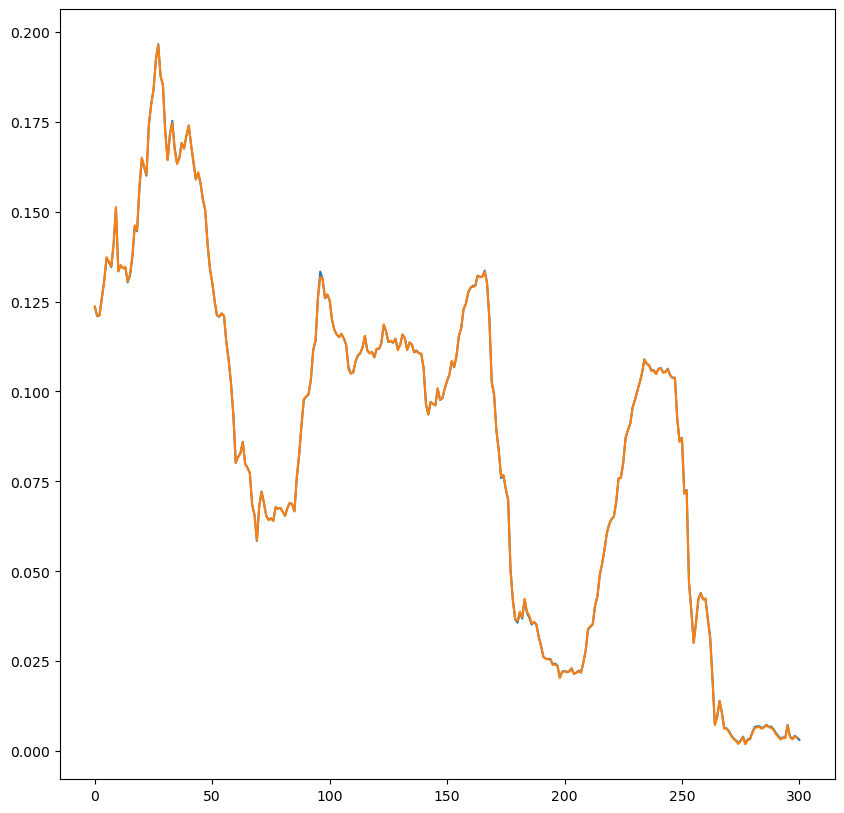

In [252]:
B = np.zeros((K, 120))
A = np.zeros((1,120))
log_prices = - df_yield_all * np.arange(1,121)/12
rfr_arr = 1/12*df_yield_all['1m'].values[:-1].reshape(1,-1) # scale to reflext maturity
ab, rfr_arr_hat, u = MLS(rfr_arr, np.vstack((np.ones((1,T)),X_)))
delta_0 = ab[0,0]
delta_1 = ab[0, 1:]

A[0,0] = -delta_0
B[:,0] = -delta_1
for i in range(1, 120):
    A[0, i] = A[0, [i-1]] + B[:, [i-1]].T @ (phi[:,[0]] - lambda_0_hat) + 0.5 * (B[:, [i-1]].T @ cap_sigma_hat @ B[:, [i-1]] +  sigma_sq_hat) - delta_0
    B[:, i] = B[:,[i-1]].T@(phi[:,1:]-lambda_1_hat) - delta_1

log_prices_fitted = (A.T + B.T@X_)

n = 5
plt.plot(- n*log_prices[f'{n}m'].values.T)
plt.plot(-n*log_prices_fitted[n-1])

0.007121289692072319


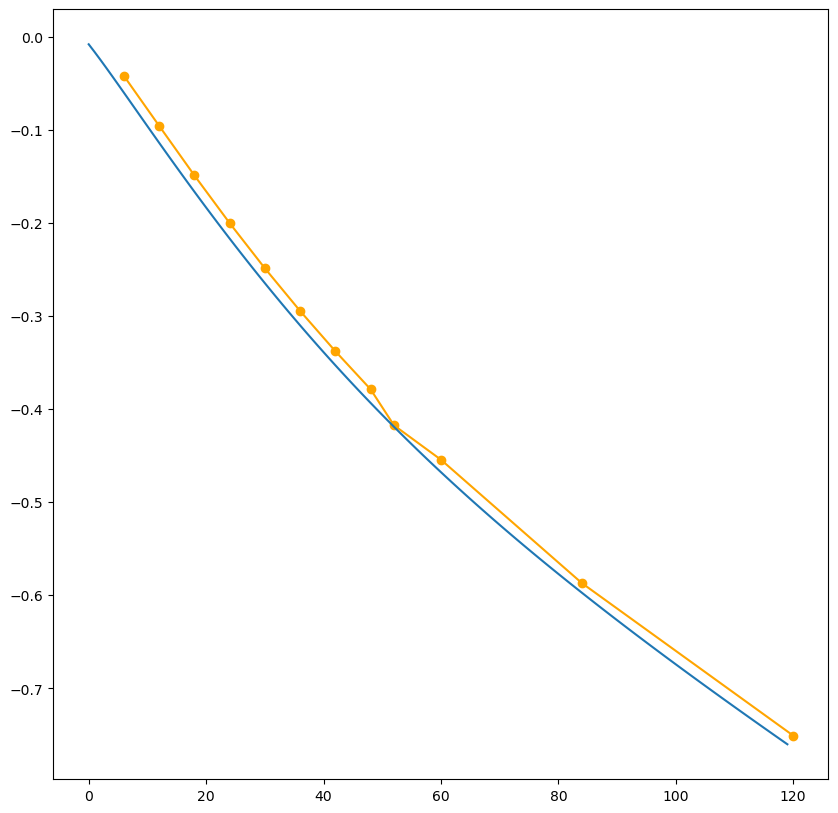

0.005914897479521252


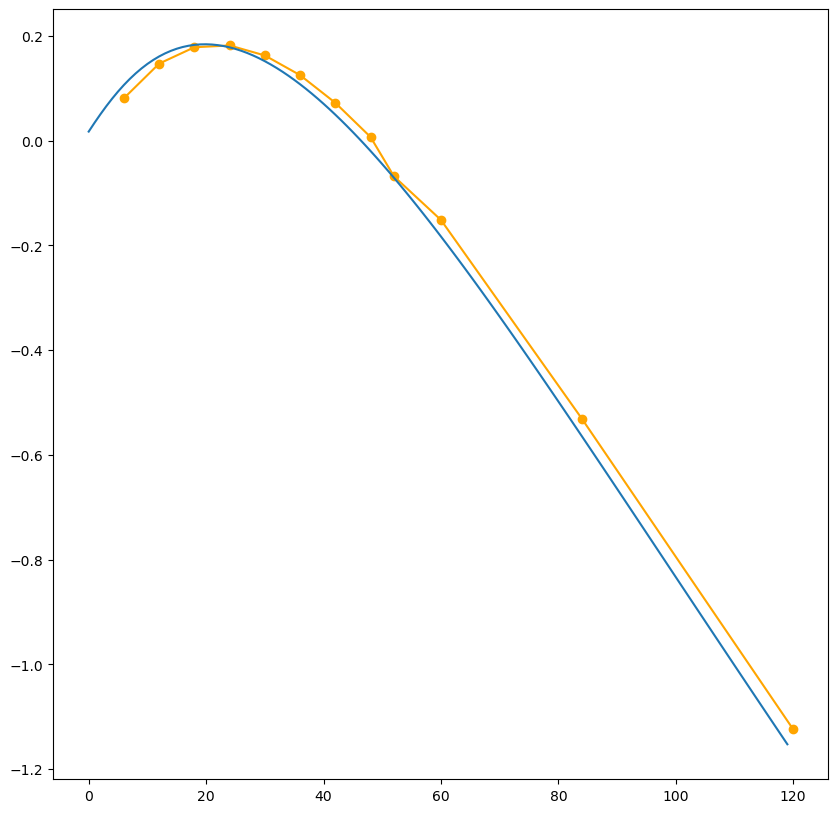

-0.0030466848866389797


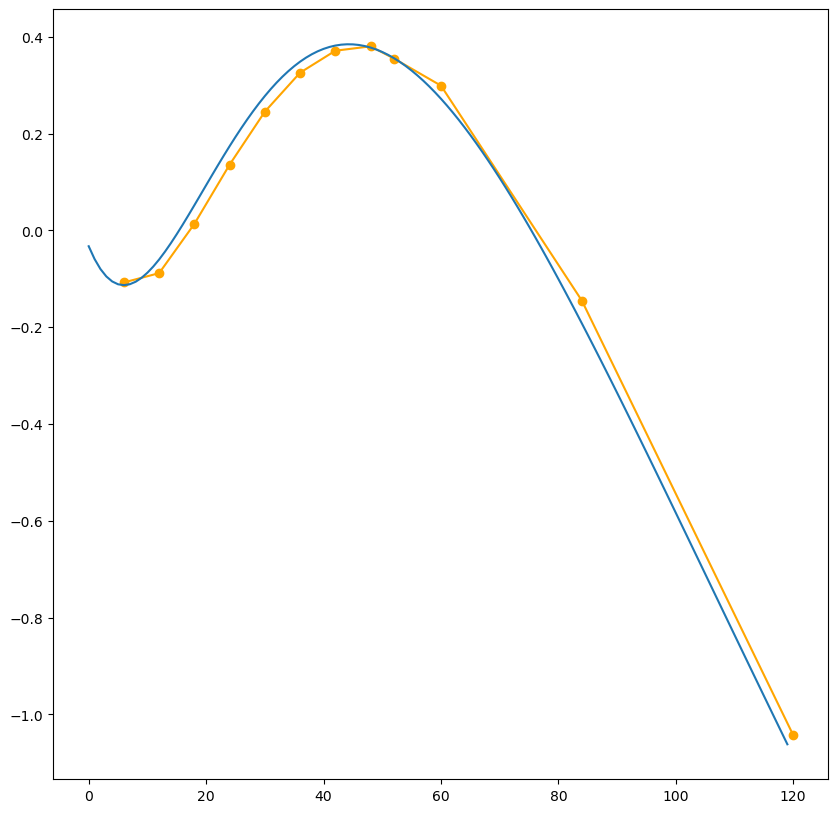

-0.0023165794580607296


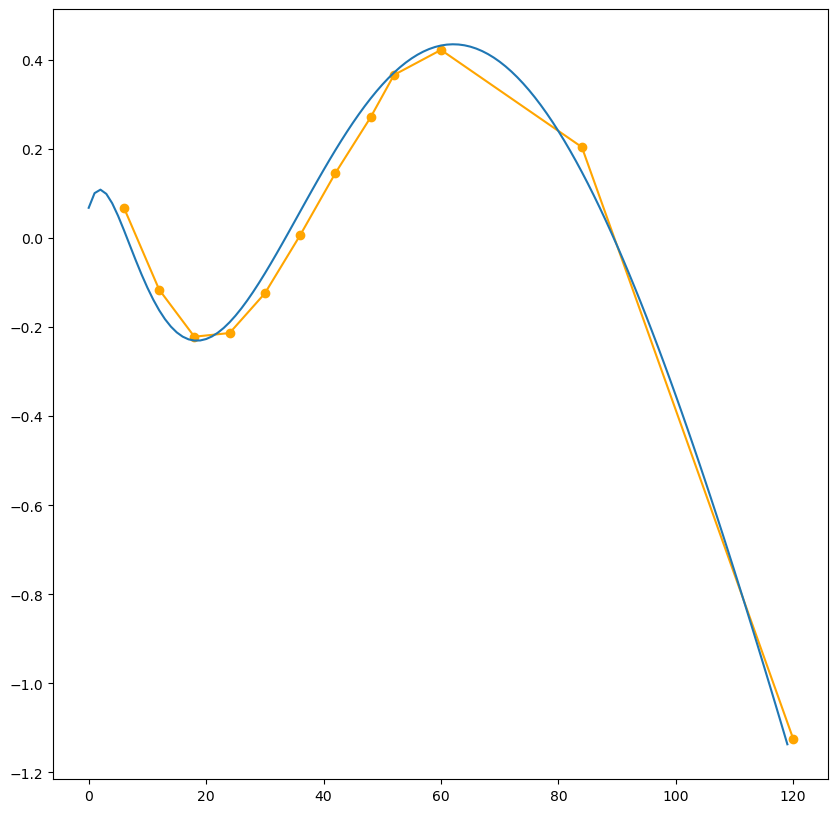

-0.06732469043512386


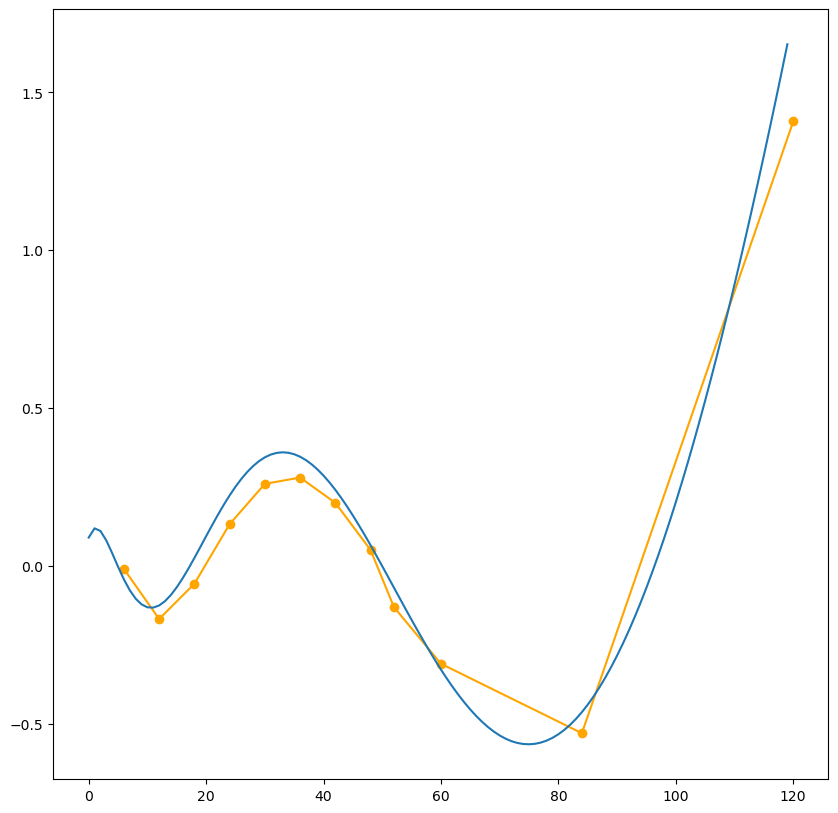

In [259]:
for i in range(5):
    print(np.mean(beta_hat[i] - B[i,np.array([6,12,18,24,30,36,42,48,52,60,84,120])-1]))
    plt.scatter([6,12,18,24,30,36,42,48,52,60,84,120], beta_hat[i], color='orange')
    plt.plot([6,12,18,24,30,36,42,48,52,60,84,120], beta_hat[i], color='orange')
    plt.plot(B[i])
    plt.show()
    

In [11]:
with np.printoptions(suppress=True, ):
    print(B[:,rx_maturities-1]-beta_hat)
rx_maturities

[[-1.022e-01  1.273e+00  1.756e+02  1.304e+04  8.412e+05  5.136e+07
   3.062e+09  1.809e+11  1.067e+13  6.298e+14  7.945e+21  3.937e+32]
 [-3.082e-01 -3.218e+01 -1.805e+03 -9.511e+04 -4.886e+06 -2.472e+08
  -1.236e+10 -6.102e+11 -2.971e+13 -1.421e+15 -4.894e+21  2.790e+32]
 [ 3.908e+00  1.237e+02  2.575e+03 -5.576e+03 -5.142e+06 -4.316e+08
  -2.789e+10 -1.628e+12 -9.039e+13 -4.885e+15 -3.774e+22 -7.933e+32]
 [-9.874e+00 -8.427e+01  3.082e+03  2.668e+05  1.471e+07  7.359e+08
   3.622e+10  1.804e+12  9.176e+13  4.770e+15  4.109e+22  1.412e+33]
 [ 4.257e+00  6.481e+02  1.719e+04  1.875e+05 -1.267e+07 -1.363e+09
  -9.430e+10 -5.769e+12 -3.364e+14 -1.923e+16 -2.030e+23 -8.214e+33]]


array([  6,  12,  18,  24,  30,  36,  42,  48,  54,  60,  84, 120])

In [12]:
with np.printoptions(suppress=True, ):
    print(beta_hat)

[[-0.042 -0.096 -0.149 -0.2   -0.249 -0.294 -0.338 -0.379 -0.417 -0.454
  -0.587 -0.751]
 [ 0.081  0.147  0.179  0.182  0.163  0.125  0.072  0.007 -0.068 -0.151
  -0.531 -1.124]
 [-0.107 -0.088  0.014  0.136  0.246  0.326  0.372  0.381  0.355  0.299
  -0.145 -1.043]
 [ 0.068 -0.116 -0.221 -0.213 -0.124  0.006  0.146  0.271  0.367  0.423
   0.204 -1.125]
 [-0.01  -0.169 -0.057  0.132  0.26   0.28   0.2    0.05  -0.131 -0.31
  -0.53   1.408]]
